In [1]:
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18

from PIL import Image

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [2]:
class CarlaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        img_dir,
        label_column,
        transform=None
    ):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        frame = str(row["frame"]).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(
            label,
            dtype=torch.float32
        )

In [3]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [5]:
test_df = pd.read_csv(
    "test/labels.csv"
)

print("Number of test samples:", len(test_df))

print(test_df.head())

Number of test samples: 3600
   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False        False                15   
1     10               True           False         True               299   
2     20               True           False         True               298   
3     30               True           False         True               297   
4     40               True           False         True               297   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
2              0         307  
3              0         258  
4              0         249  


In [6]:
test_ped = CarlaDataset(
    test_df,
    "test/rgb-front",
    "has_pedestrian",
    transform
)

In [7]:
test_vehicle = CarlaDataset(
    test_df,
    "test/rgb-front",
    "has_vehicle",
    transform
)

In [8]:
test_traffic = CarlaDataset(
    test_df,
    "test/rgb-front",
    "has_traffic_light",
    transform
)

In [9]:
test_ped_loader = DataLoader(
    test_ped,
    batch_size=32,
    shuffle=False
)

test_vehicle_loader = DataLoader(
    test_vehicle,
    batch_size=32,
    shuffle=False
)

test_traffic_loader = DataLoader(
    test_traffic,
    batch_size=32,
    shuffle=False
)

In [13]:
def create_model():

    from torchvision.models import resnet18

    model = resnet18(weights=None)  # instead of pretrained=False
    

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    return model

In [14]:
ped_model = create_model()

ped_model.load_state_dict(
    torch.load(
        "pedestrian_model.pth",
        map_location=device
    )
)

ped_model = ped_model.to(device)

ped_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [15]:
vehicle_model = create_model()

vehicle_model.load_state_dict(
    torch.load(
        "vehicle_model.pth",
        map_location=device
    )
)

vehicle_model = vehicle_model.to(device)

vehicle_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
traffic_model = create_model()

traffic_model.load_state_dict(
    torch.load(
        "traffic_light_model.pth",
        map_location=device
    )
)

traffic_model = traffic_model.to(device)

traffic_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
def evaluate_model(model, loader):

    model.eval()

    true_labels = []
    predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.sigmoid(
                outputs
            )

            predicted = (
                probabilities >= 0.5
            ).float()

            true_labels.extend(
                labels.numpy()
            )

            predictions.extend(
                predicted.cpu()
                .numpy()
                .flatten()
            )

    precision = precision_score(
        true_labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        true_labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        true_labels,
        predictions,
        zero_division=0
    )

    return (
        true_labels,
        predictions,
        precision,
        recall,
        f1
    )

In [18]:
ped_results = evaluate_model(
    ped_model,
    test_ped_loader
)

print("\nPedestrian Model")
print("----------------")

print(
    "Precision:",
    round(ped_results[2], 4)
)

print(
    "Recall:",
    round(ped_results[3], 4)
)

print(
    "F1-score:",
    round(ped_results[4], 4)
)


Pedestrian Model
----------------
Precision: 0.572
Recall: 0.1912
F1-score: 0.2866


In [19]:
traffic_results = evaluate_model(
    traffic_model,
    test_traffic_loader
)

print("\nTraffic Light Model")
print("-------------------")

print(
    "Precision:",
    round(traffic_results[2], 4)
)

print(
    "Recall:",
    round(traffic_results[3], 4)
)

print(
    "F1-score:",
    round(traffic_results[4], 4)
)


Traffic Light Model
-------------------
Precision: 0.9156
Recall: 0.9907
F1-score: 0.9517


In [20]:
vehicle_results = evaluate_model(
    vehicle_model,
    test_vehicle_loader
)

print("\nVehicle Model")
print("-------------")

print(
    "Precision:",
    round(vehicle_results[2], 4)
)

print(
    "Recall:",
    round(vehicle_results[3], 4)
)

print(
    "F1-score:",
    round(vehicle_results[4], 4)
)


Vehicle Model
-------------
Precision: 0.9863
Recall: 0.8
F1-score: 0.8834


In [21]:
results_df = pd.DataFrame({

    "Model": [
        "Pedestrian",
        "Vehicle",
        "Traffic Light"
    ],

    "Precision": [
        ped_results[2],
        vehicle_results[2],
        traffic_results[2]
    ],

    "Recall": [
        ped_results[3],
        vehicle_results[3],
        traffic_results[3]
    ],

    "F1-score": [
        ped_results[4],
        vehicle_results[4],
        traffic_results[4]
    ]

})

print("\nFinal Results")
print(
    results_df.to_string(index=False)
)


Final Results
        Model  Precision   Recall  F1-score
   Pedestrian   0.572034 0.191218  0.286624
      Vehicle   0.986301 0.800000  0.883436
Traffic Light   0.915594 0.990712  0.951673


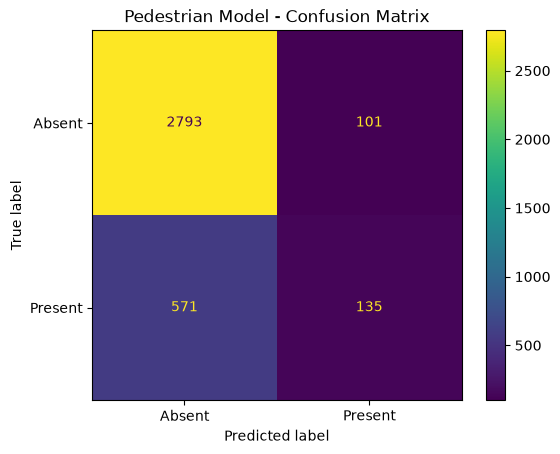

In [22]:
cm_ped = confusion_matrix(
    ped_results[0],
    ped_results[1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ped,
    display_labels=["Absent", "Present"]
)

disp.plot()

plt.title(
    "Pedestrian Model - Confusion Matrix"
)

plt.show()

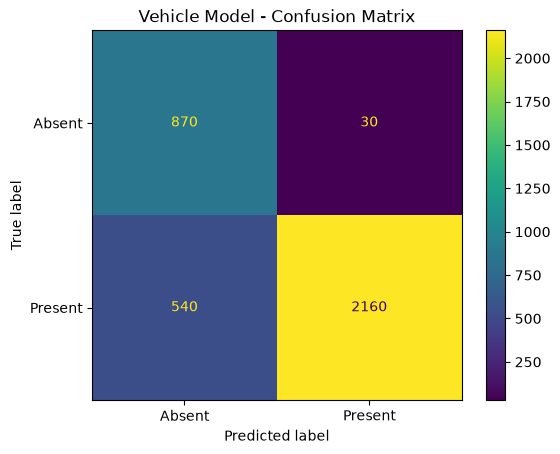

In [23]:
cm_vehicle = confusion_matrix(
    vehicle_results[0],
    vehicle_results[1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_vehicle,
    display_labels=["Absent", "Present"]
)

disp.plot()

plt.title(
    "Vehicle Model - Confusion Matrix"
)

plt.show()

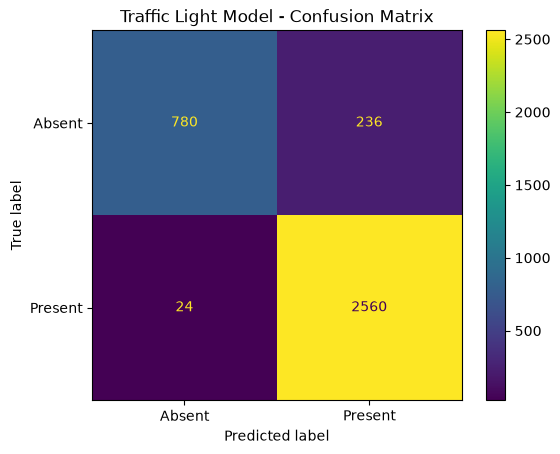

In [24]:
cm_traffic = confusion_matrix(
    traffic_results[0],
    traffic_results[1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_traffic,
    display_labels=["Absent", "Present"]
)

disp.plot()

plt.title(
    "Traffic Light Model - Confusion Matrix"
)

plt.show()

In [25]:
recalls = {

    "Pedestrian":
        ped_results[3],

    "Vehicle":
        vehicle_results[3],

    "Traffic Light":
        traffic_results[3]
}

print("\nRecall Comparison")
print("-----------------")

for model, recall in recalls.items():

    print(
        f"{model}: {recall:.4f}"
    )

lowest_model = min(
    recalls,
    key=recalls.get
)

print(
    f"\nLowest recall: {lowest_model}"
)


Recall Comparison
-----------------
Pedestrian: 0.1912
Vehicle: 0.8000
Traffic Light: 0.9907

Lowest recall: Pedestrian


In [26]:
print(test_df["has_pedestrian"].value_counts())
print()
print(test_df["has_pedestrian"].value_counts(normalize=True))

has_pedestrian
False    2894
True      706
Name: count, dtype: int64

has_pedestrian
False    0.803889
True     0.196111
Name: proportion, dtype: float64


In [27]:
minimum_recall = 0.95

pedestrian_recall = ped_results[3]

print("\nPedestrian Safety Requirement")
print("----------------------------")

print(
    f"Required recall: {minimum_recall:.2f}"
)

print(
    f"Actual recall: {pedestrian_recall:.4f}"
)

if pedestrian_recall >= minimum_recall:

    print(
        "PASS: Pedestrian recall "
        "meets the safety threshold."
    )

else:

    print(
        "FAIL: Pedestrian recall "
        "does not meet the safety threshold."
    )


Pedestrian Safety Requirement
----------------------------
Required recall: 0.95
Actual recall: 0.1912
FAIL: Pedestrian recall does not meet the safety threshold.
